In [21]:
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import pylab

weeklies = pd.read_csv("weeklies.txt")
t_test = stats.ttest_ind(weeklies.current, weeklies.lastyear)

t_test.confidence_interval(confidence_level= 0.9)

ConfidenceInterval(low=np.float64(-25.66806265492842), high=np.float64(5.589115286507374))

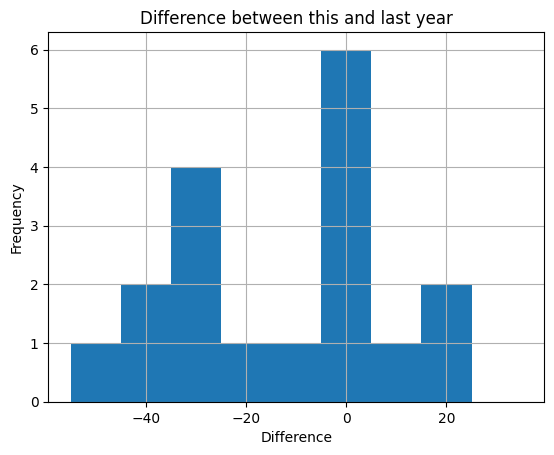

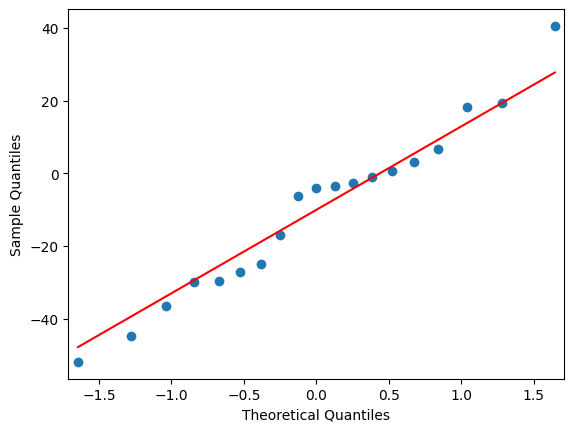

TtestResult(statistic=np.float64(-1.853565220621631), pvalue=np.float64(0.08026526054859673), df=np.int64(18))

In [ ]:
diff_vec = weeklies.current - weeklies.lastyear
ax = diff_vec.hist(bins=range(-55,45,10))

ax.set_title("Difference between this and last year")
ax.set_xlabel("Difference")
ax.set_ylabel("Frequency")

sm.qqplot(diff_vec, line="s")
pylab.show()

In [32]:
stats.ttest_1samp(diff_vec, 0)


TtestResult(statistic=np.float64(-1.853565220621631), pvalue=np.float64(0.08026526054859673), df=np.int64(18))

In [ ]:
import numpy as np
def skewness(data):
    mean = data.mean()
    top = np.pow(data - mean, 3).mean()
    bottom = np.pow(np.pow(data - mean, 2).mean(), 1.5)
    return top / bottom

skewness(diff_vec)

np.float64(0.12838147993895702)

In [40]:
def kurt(data):
    mean = data.mean()
    top = np.pow(data - mean, 4).mean()
    bottom = np.pow(np.pow(data - mean, 2).mean(), 2)
    return (top / bottom) - 3

kurt(diff_vec)

np.float64(-0.4401951705737881)

In [44]:
def kim_and_white(data):
    quantile = np.quantile(data, [0.25, 0.5, 0.75])
    return ((quantile[2] + quantile[0]) - 2 * quantile[1]) / (quantile[2] - quantile[0])

kim_and_white(diff_vec)

np.float64(-0.6108358110340271)